<a href="https://colab.research.google.com/github/MdMukidurRahman/MdMukidurRahman/blob/main/Copy_of_Module_7_Exploring%2C_Plotting%2C_%26_Modifying_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**_Overview_**

This notebook will cover pp.200 - 225 in Chapter 6 of our text *Python for MBAs*.

We will work through these exercises during the Monday March 31 class.

These exercises are going to introduce you to the fundamental operations of data analysis in **pandas**, including sorting, filtering, and plotting data frames. These concepts are introduced in the context of the Dig case study
and datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
#Import Simplified orders.csv file into Python and create data frame named df_orders
df_orders=pd.read_csv('/content/drive/My Drive/CIS530 Data/Simplified orders.csv')
df_orders.head()

#Import Summarized orders.csv file into Python and create data frame named df_summarized_orders
df_summarized_orders=pd.read_csv('/content/drive/My Drive/CIS530 Data/Summarized orders.csv')
df_summarized_orders.head()

#The data description for both these data frames are on pp. 171-172 of our text
#Verify data frames were created successfully




,RESTAURANT_NAME,day,NUM_ORDERS,PERC_DELIVERY
0,Bryant Park,1/1/2018,373,0.0
1,Bryant Park,1/2/2018,789,0.0
2,Bryant Park,1/3/2018,818,0.0
3,Bryant Park,1/4/2018,782,0.0
4,Bryant Park,1/5/2018,719,0.0


**Column Types**

Each column in a pandas data frame has its own data type.

The info() function provides the data type of each column.


In pandas an object data type is a string/text column.

Using the df_orders pandas data frame, complete the following coding tasks.


In [ ]:
#run the info() function
df_orders.info()

#convert the column DATETIME to a datetime data type
df_orders.DATETIME=pd.to_datetime(df_orders.DATETIME)

#run the info() function again
df_orders.info()

#Extract the day of the week from the DATETIME column
df_orders.DATETIME.dt.day_name().head()

,DATETIME
0,Thursday
1,Thursday
2,Saturday
3,Saturday
4,Sunday


**_Exploring Data in Pandas (Chapter 6 section 5)_**

The function **_value_counts()_** returns the frequency of each value in a series (column).

If you use the normalize=True (case sensitive) argument inside the function, the percentage will be returned.

In [ ]:
#Find the number of times each category/level of TYPE appears. Then find the percentages.

#counts
df_orders.TYPE.value_counts(normalize=True)
#frequency
#Wdelete this and insert your code here

,proportion
TYPE,
IN_STORE,0.717627
PICKUP,0.168162
DELIVERY,0.114211


<Axes: xlabel='TYPE'>

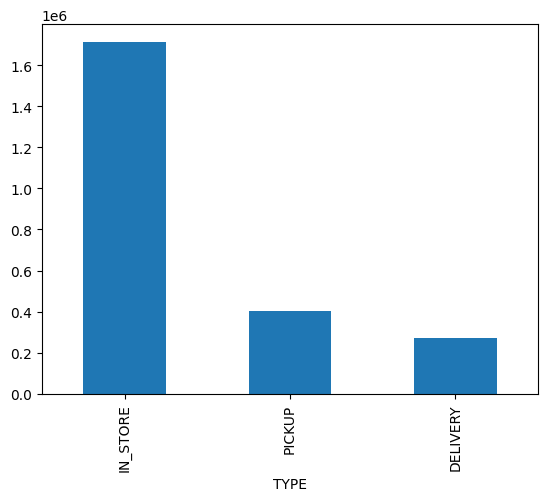

In [ ]:
#Create a bar chart for the TYPE column

df_orders.TYPE.value_counts().plot(kind="bar")

In [ ]:
#Which restaurant achieves the highest sales volume? And which lags behind?
df_summarized_orders.RESTAURANT_NAME.value_counts()

df_summarized_orders.groupby('RESTAURANT_NAME').NUM_ORDERS.sum().sort_values(ascending=False)


,NUM_ORDERS
RESTAURANT_NAME,
NYU,430860
Midtown,325265
Williamsburg,314674
Flatiron,281983
Upper West Side,281186
Upper East Side,275001
Columbia,250810
Bryant Park,227445


In [ ]:
#Determine how many times each restaurant appears in the df_summarized_orders data frame
#Remind yourself what the data frame looks like

#delete this and insert your code here

#Number of times each restaurant appears in df_summarized_orders
#delete this and insert your code here

**_Describing Numerical Columns and Plotting Histograms_**

Not all columns (series) are appropriate for the **value_counts()** function. Try running **value_counts()** on a numerical column.

**value_counts()_** returns the count of each unique value in the column. **value_counts()** is more appropriate for non-numeric columns.

If you want to summarize a numerical column (float or integer data type), use the **describe()** function. The **describe()** function provides the descriptive statistics for a numeric column.

<Axes: ylabel='Frequency'>

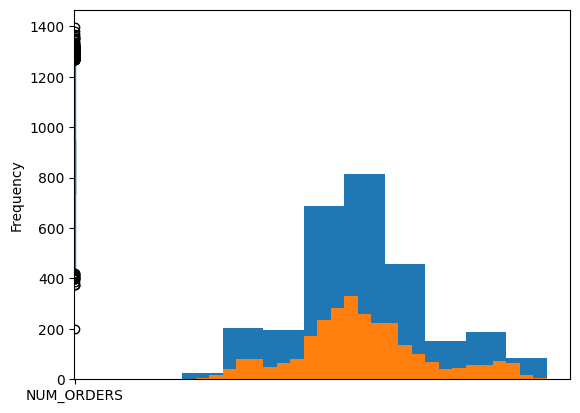

In [ ]:
#Run value_counts() on the NUM_ORDERS column in df_summarized_orders
df_summarized_orders.NUM_ORDERS.value_counts()

#Run the describe() function on NUM_ORDERS column in df_summarized_orders
df_summarized_orders.NUM_ORDERS.describe()

#Create a boxplot of NUM_ORDERS
df_summarized_orders.NUM_ORDERS.plot(kind='box')

#Create a histogram of NUM_ORDERS
df_summarized_orders.NUM_ORDERS.plot(kind='hist')

#Modify the number of bins for the histogram
df_summarized_orders.NUM_ORDERS.plot(kind='hist',bins=30)

**_Aggregation (Chapter 6 section 5.3)_**

Both **_value_counts()_** and **_describe()_** functions aggregate the data in some way. That is, these functions take every value in the column and combine them in some manner.

In **pandas** these are the most widely used aggregations.

**sum()** - sum every value in the columns

**max()** - finds the maximum value in the column

**min()** - finds the minimum value in the column

**mean()** - finds the mean (average) of the values in the column

**median()** - finds the median value in the column

**std()** - finds the standard deviation of values in the column

**unique().tolist()** - returns a list that contains the unique elements in that column


In [ ]:
#Find the average number of drinks per order
df_orders.DRINKS.mean()

#Find the unique restaurants in the df_summarized_orders data
df_summarized_orders.RESTAURANT_NAME.unique().tolist()

['Bryant Park',
 'Columbia',
 'Flatiron',
 'Midtown',
 'NYU',
 'Upper East Side',
 'Upper West Side',
 'Williamsburg']

**_Filtering Data Frames (Chapter 6 section 6)_**

**Filtering** rows/observations from a data frame means removing unwanted rows/observations.

Suppose we only want orders at one specific restaurant.

To filter in **pandas** you have to create a list of True/False values with as many rows as the data frame.

True for those rows you want to keep and False otherwise. You then put this list between square brackets after the data frame name.

To create this list of True/False values, you must understand **logical** operations in Python.

A **logical** operation will return a series (column) with as many entries as the original series containing a True if a certain condition is met, and False otherwise.

In [ ]:
#Check whether each order has at least one drink
(df_orders.DRINKS >=1).head()

#Number of orders that had at least one drink
(df_orders.DRINKS >=1).sum()

#Which orders had exactly two drinks
(df_orders.DRINKS ==1)

#Number of orders that had exactly two drinks
(df_orders.DRINKS ==1).sum()

#Percentage of orders that had exactly two drinks
(df_orders.DRINKS ==1).value_counts(normalize=True)

#Create a data frame with the orders than have cookies
df_orders_cookies=df_orders[df_orders.COOKIES >0]
df_orders_cookies.head

#number of rows in df_orders_cookies (number of orders with cookies)
df_orders_cookies.shape

#sum up the number of orders with cookies, no data frame being created
(df_orders.DRINKS ==1).sum()

np.int64(154423)

**_Multiple Conditions for Filtering_**

You can apply multiple comparisons by combining the simple comparisons.

Python notation: for "and", use the ampersand symbol, &

For "or", use the vertical bar, |

In [ ]:
#Find the percentage of orders with at least one drink AND exactly two cookies
((df_orders.DRINKS >=1)&(df_orders.COOKIES==2)).value_counts(normalize=True)

#Find the percentage of orders with at least one drink OR exactly two cookies
((df_orders.DRINKS >=1)|(df_orders.COOKIES==2)).value_counts(normalize=True)

,proportion
False,0.866356
True,0.133644


**_The isin() function (More Logic)_**

The **isin()** function allows you to check if values of a column are contained is a list of several values.

For example, suppose you wanted to check if each restaurant is either restaurant ID R10001 or R10002 (Columbia and Midtown restaurants).

In [ ]:
#Examine the boolean values that isin() returns
#delete this and insert your code here

#how many orders were placed at the Columbia and Midtown stores
#delete this and insert your code here

**_Operating on Columns (Chapter 6 section 7)_**
**_Arithmetic on Columns_**

Arithmetic is the simplest computation you can perform on numeric columns.

Dig buys paper bowls and for food service in packs of 100. You want to figure out the number of packs each restaurant used on each day.

In [ ]:
#Number of packs of paper bowls each restaurant uses on each day
#delete this and insert your code here

In [ ]:
#create a new column in the df_orders data frame named extras that is the number of
#cookies and drinks each order contained


In [ ]:
#create a new column in the df_summarized data frame named NUM_NON_DELIVERIES that
#is the number of nondelivery orders from each store on each day

#multiple the number of orders by the proportion of nondelivery orders

#delete this and insert your code here

**_Missing Values_**

**pandas** denotes missing values as NaN (not a number). If you try to perform mathematical calculations on a missing value, a missing value is returned.

**isnull()** returns the number of series (column) of Boolean values that is True if the observation is missing and False if the obersvation is not missing. This function can be used to detect if a column has missing values.

**notnull()** performs the opposite function of **isnul()**. **notnull()** returns a value of True if the observation is not missing and False if the observation is missing.

In [ ]:
#Run isnull() on the MAIN column in the df_orders data frame
#delete this and insert your code here

#Determine the number of orders with bowls
#delete this and insert your code here